# Biodiversity in National Parks
## National Park Service Species Analysis

### Project Goal
This project analyzes biodiversity data from the National Park Service to answer:

1. What is the distribution of conservation status for species?
2. Are certain categories of species more likely to be protected?
3. Are differences between species category and conservation status statistically significant?
4. Are certain categories more likely to be endangered?
5. Which species are most prevalent, and how are they distributed across parks?

### Data Sources
- `species_info.csv`
- `observations.csv`

> Note: This dataset is inspired by real data but is largely fictional.


In [21]:
# 1) Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [23]:
# 2) Load data
species = pd.read_csv("species_info.csv")
observations = pd.read_csv("observations.csv")

print("species shape:", species.shape)
print("observations shape:", observations.shape)

species.head()


species shape: (5824, 4)
observations shape: (23296, 3)


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


## Interpretation: Data Overview
The dataset contains two tables: one with species information and conservation status, and one with park-level observation counts.  
After loading and inspecting both tables, the structure appears suitable for joining on `scientific_name` and answering the project questions.


In [26]:
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [27]:
# 3) Initial data checks
print(species.info())
print("\nMissing values in species:\n", species.isna().sum())

print("\nObservations info:")
print(observations.info())
print("\nMissing values in observations:\n", observations.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None

Missing values in species:
 category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64

Observations info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.

In [29]:
# 4) Data cleaning
# Fill missing conservation status as "No Intervention"
species["conservation_status"] = species["conservation_status"].fillna("No Intervention")

# Standardize text columns for consistency
for col in ["category", "scientific_name", "common_names", "conservation_status"]:
    if col in species.columns:
        species[col] = species[col].astype(str).str.strip()

for col in ["scientific_name", "park_name"]:
    if col in observations.columns:
        observations[col] = observations[col].astype(str).str.strip()

species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention
1,Mammal,Bos bison,"American Bison, Bison",No Intervention
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Intervention
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",No Intervention
4,Mammal,Cervus elaphus,Wapiti Or Elk,No Intervention


## Interpretation: Missing Values and Cleaning
Most missing values are in `conservation_status`. These were filled with `"No Intervention"` to indicate species without a listed protection category.  
This allows consistent counting and comparison across all species during analysis.


In [71]:
# 5) Q1: Distribution of conservation status
status_counts = species["conservation_status"].value_counts().reset_index()
status_counts.columns = ["conservation_status", "count"]
status_counts

,conservation_status,count
0,No Intervention,5633
1,Species of Concern,161
2,Endangered,16
3,Threatened,10
4,In Recovery,4


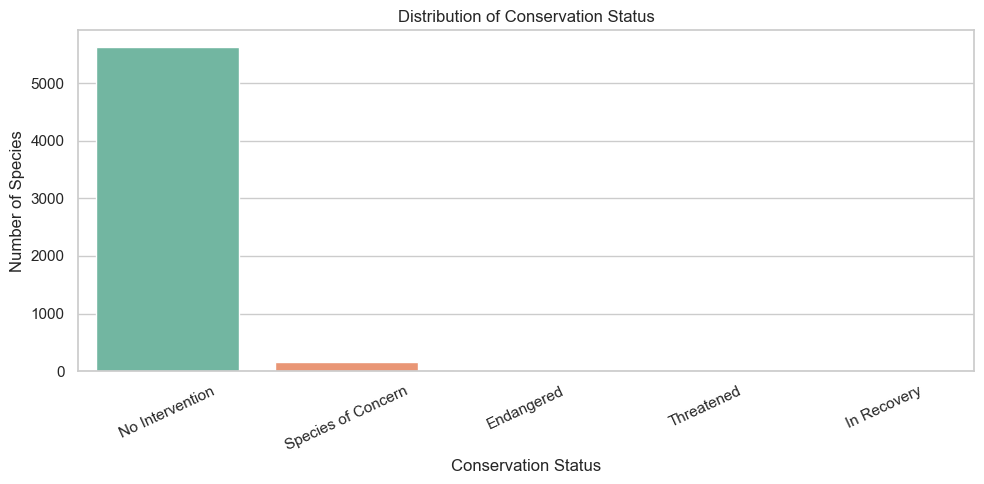

In [72]:
plt.figure(figsize=(10,5))
sns.barplot(data=status_counts, x="conservation_status", y="count", palette="Set2",hue='conservation_status',legend=False )
plt.title("Distribution of Conservation Status")
plt.xlabel("Conservation Status")
plt.ylabel("Number of Species")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Interpretation: Distribution of Conservation Status
The conservation status distribution shows that the majority of species are classified as `"No Intervention"`, with smaller counts in protected groups such as `Species of Concern`, `Threatened`, and `Endangered`.  
This suggests most recorded species are not currently listed as at-risk in this dataset.


In [47]:
# 6) Q2: Are certain categories more likely to be protected?

# Protected = anything other than "No Intervention"
species["is_protected"] = species["conservation_status"] != "No Intervention"

protected_by_category = (
    species.groupby("category")["is_protected"]
    .agg(total_species="count", protected_species="sum")
    .reset_index()
)
protected_by_category["protected_rate"] = (
    protected_by_category["protected_species"] /
    protected_by_category["total_species"]
)
protected_sorted = protected_by_category.sort_values("protected_rate", ascending=False)
protected_sorted

,category,total_species,protected_species,protected_rate
3,Mammal,214,38,0.177570
1,Bird,521,79,0.151631
0,Amphibian,80,7,0.087500
2,Fish,127,11,0.086614
5,Reptile,79,5,0.063291
4,Nonvascular Plant,333,5,0.015015
6,Vascular Plant,4470,46,0.010291


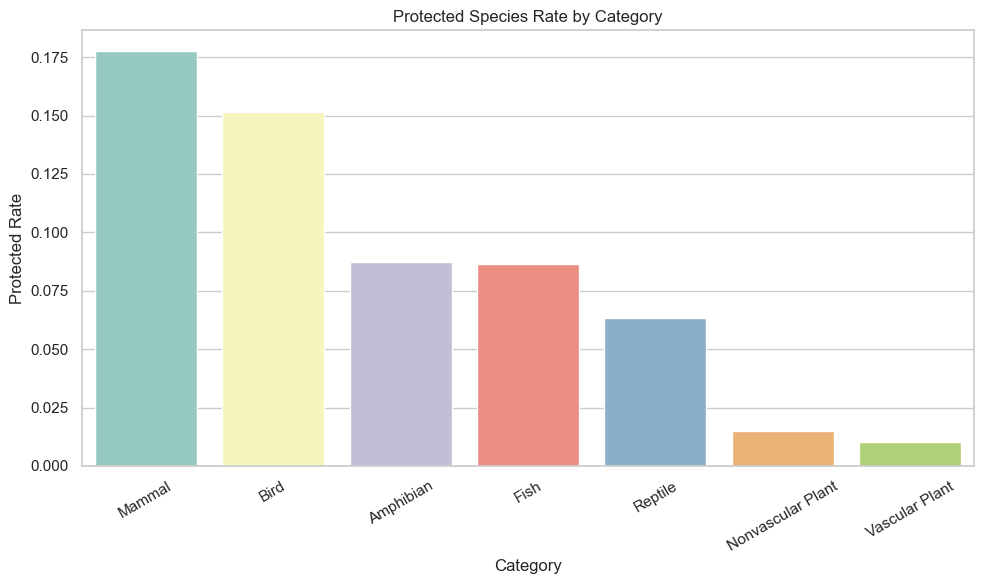

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=protected_sorted,
    x="category", y="protected_rate", palette="Set3", hue='category', legend=False
)
plt.title("Protected Species Rate by Category")
plt.xlabel("Category")
plt.ylabel("Protected Rate")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Interpretation: Protected Species by Category
When grouping by category, the proportion of protected species differs across groups.  
This indicates that some categories (for example, mammals or birds in many biodiversity datasets) may be more likely to receive conservation protection than others.


In [51]:
# 7) Q3: Statistical significance (Chi-square test)
contingency = pd.crosstab(species["category"], species["is_protected"])
chi2, pval, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", pval)
print("Degrees of freedom:", dof)
print("\nContingency table:\n", contingency)

if pval < 0.05:
    print("\nResult: There is significant relationship between species category and protection status.")
else:
    print("\nResult: No significant relationship between species category and protection status.")


Chi-square statistic: 469.5114395774195
p-value: 3.095911909904608e-98
Degrees of freedom: 6

Contingency table:
 is_protected       False  True 
category                       
Amphibian             73      7
Bird                 442     79
Fish                 116     11
Mammal               176     38
Nonvascular Plant    328      5
Reptile               74      5
Vascular Plant      4424     46

Result: There is significant relationship between species category and protection status.


## Interpretation: Chi-Square Test (Category vs Protection)
The chi-square test checks whether protection status is independent of species category.  
- If `p < 0.05`: there is a statistically significant association between category and protection status.  
- If `p >= 0.05`: there is not enough evidence of a significant association in this dataset.


In [84]:
# 8) Q4: Are certain species categories more likely to be endangered?
species["is_endangered"] = species["conservation_status"] == "Endangered"

# 2) Endangered rate by category
endangered_by_cat = (
    species.groupby("category")["is_endangered"]
    .agg(total_species="count", endangered_species="sum")
    .reset_index()
)
endangered_by_cat["endangered_rate"] = (
    endangered_by_cat["endangered_species"] / endangered_by_cat["total_species"]
)

endangered_by_cat = endangered_by_cat.sort_values("endangered_rate", ascending=False)
endangered_by_cat

,category,total_species,endangered_species,endangered_rate
3,Mammal,214,7,0.032710
2,Fish,127,3,0.023622
0,Amphibian,80,1,0.012500
1,Bird,521,4,0.007678
6,Vascular Plant,4470,1,0.000224
4,Nonvascular Plant,333,0,0.000000
5,Reptile,79,0,0.000000


In [89]:
#Top_4 endangered by category species
endangered_by_cat = endangered_by_cat.head(4).copy()

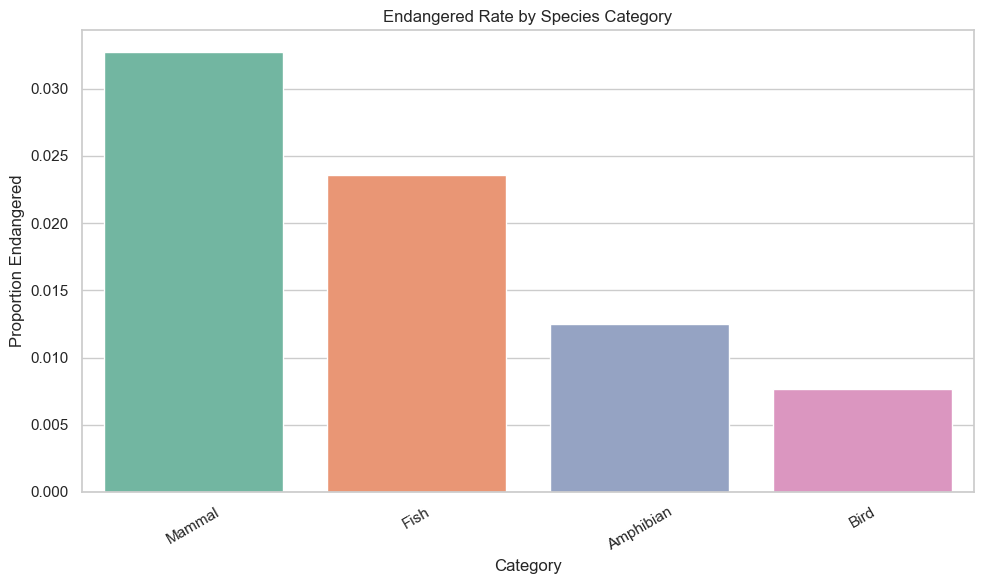

In [88]:
# Plot
plt.figure(figsize=(10,6))
sns.barplot(data=endangered_by_cat, x="category", y="endangered_rate", palette="Set2", hue='category', legend=False)
plt.title("Endangered Rate by Species Category")
plt.xlabel("Category")
plt.ylabel("Proportion Endangered")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Endangered Species by Category

This visualization shows the proportion of species classified as **Endangered** within each category.  
Among the categories shown, **Mammals** have the highest endangered proportion, followed by **Fish**, **Amphibians**, and **Birds**. This suggests that endangered risk is not evenly distributed across species groups.

These differences indicate that certain categories may require more targeted conservation attention.  
To confirm whether these observed differences are statistically meaningful, a chi-square test should be used on category versus endangered status.


In [92]:
# Significance test for endangered specifically
cont_end = pd.crosstab(species["category"], species["is_endangered"])
chi2, pval, dof, expected = chi2_contingency(cont_end)

print("Chi-square statistic:", chi2)
print("p-value:", pval)
print("Degrees of freedom:", dof)
print("\nContingency table:\n", cont_end)

if pval < 0.05:
    print("\nResult: endangered status varies significantly by category.")
else:
    print("\nResult: there is no statistically significant evidence that endangered status differs by category.")

Chi-square statistic: 109.25114513811222
p-value: 2.924654644709551e-21
Degrees of freedom: 6

Contingency table:
 is_endangered      False  True 
category                       
Amphibian             79      1
Bird                 517      4
Fish                 124      3
Mammal               207      7
Nonvascular Plant    333      0
Reptile               79      0
Vascular Plant      4469      1

Result: endangered status varies significantly by category.


### Statistical Significance Test (Endangered Status)

A chi-square test of independence was used to examine whether **species category** and **endangered status** are associated.

- `cont_end` creates a contingency table of category by `is_endangered` (True/False).
- `chi2_contingency(cont_end)` computes the test statistic and p-value.
- The p-value is used to evaluate significance:
  - If `p < 0.05`, endangered status varies significantly by category.
  - If `p >= 0.05`, there is no statistically significant evidence that endangered status differs by category.


In [52]:
# 9) Q5: Most prevalent species and distribution across parks

# Merge datasets
merged = observations.merge(species, on="scientific_name", how="left")
merged.head()

,scientific_name,park_name,observations,category,common_names,conservation_status,is_protected
0,Vicia benghalensis,Great Smoky Mountains National Park,68,Vascular Plant,"Purple Vetch, Reddish Tufted Vetch",No Intervention,False
1,Neovison vison,Great Smoky Mountains National Park,77,Mammal,American Mink,No Intervention,False
2,Prunus subcordata,Yosemite National Park,138,Vascular Plant,Klamath Plum,No Intervention,False
3,Abutilon theophrasti,Bryce National Park,84,Vascular Plant,Velvetleaf,No Intervention,False
4,Githopsis specularioides,Great Smoky Mountains National Park,85,Vascular Plant,Common Bluecup,No Intervention,False


In [53]:
# Total observations by scientific name
top_species = (
    merged.groupby(["scientific_name", "common_names"], as_index=False)["observations"]
    .sum()
    .sort_values("observations", ascending=False)
)

top_species.head(10)


,scientific_name,common_names,observations
5240,Streptopelia decaocto,"Eurasian Collared Dove, Eurasian Collared-Dove",1785
5241,Streptopelia decaocto,Eurasian Collared-Dove,1785
5239,Streptopelia decaocto,Eurasian Collared Dove,1785
2565,Holcus lanatus,"Common Velvet Grass, Velvetgrass",1780
2566,Holcus lanatus,"Common Velvetgrass, Velvetgrass, Yorkshire Fog",1780
2567,Holcus lanatus,"Common Velvetgrass, Yorkshire-Fog",1780
1144,Castor canadensis,American Beaver,1725
1146,Castor canadensis,Beaver,1725
1145,Castor canadensis,"American Beaver, Beaver",1725
2674,Hypochaeris radicata,"Spotted Cats-Ear, Hairy Cats-Ear, Gosmore",1720


In [54]:
# Pick the most observed species
most_observed_species = top_species.iloc[0]["scientific_name"]
most_observed_common = top_species.iloc[0]["common_names"]
print("Most observed species:", most_observed_species)
print("Common name(s):", most_observed_common)


Most observed species: Streptopelia decaocto
Common name(s): Eurasian Collared Dove, Eurasian Collared-Dove


## Interpretation: Most Observed Species
By summing observations across parks, we identify the most frequently observed species in the dataset.  
This species is not necessarily the most abundant in nature, but it is the one with the highest recorded observations in these park records.


In [57]:
# Distribution of the most observed species across parks
species_park_dist = (
    merged[merged["scientific_name"] == most_observed_species]
    .groupby("park_name", as_index=False)["observations"]
    .sum()
    .sort_values("observations", ascending=False)
)

species_park_dist


,park_name,observations
2,Yellowstone National Park,2313
3,Yosemite National Park,1371
0,Bryce National Park,903
1,Great Smoky Mountains National Park,768


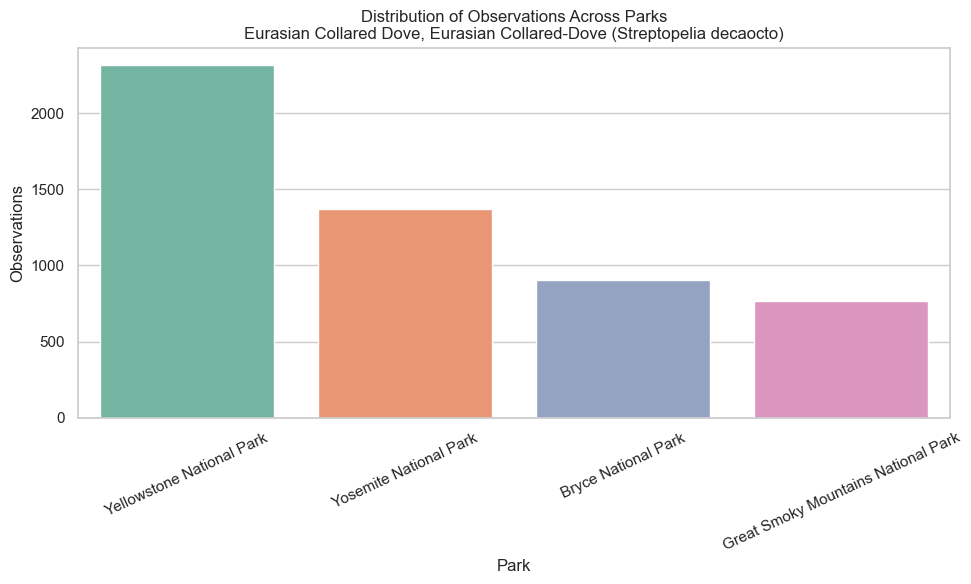

In [58]:
plt.figure(figsize=(10,6))
sns.barplot(data=species_park_dist, x="park_name", y="observations", palette="Set2", hue='park_name', legend=False)
plt.title(f"Distribution of Observations Across Parks\n{most_observed_common} ({most_observed_species})")
plt.xlabel("Park")
plt.ylabel("Observations")   
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


## Interpretation: Distribution of the Most Observed Species Across Parks
The park-level bar chart shows how observations of the most observed species vary by location.  
Differences between parks may reflect habitat suitability, park size, sampling effort, or survey frequency.


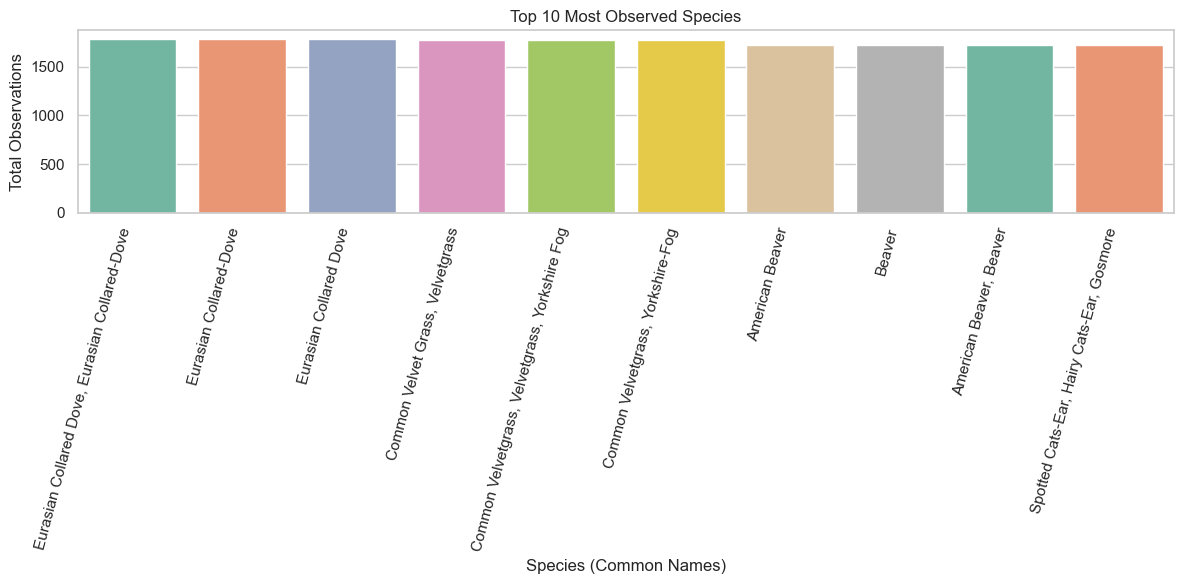

In [59]:
# 10) Extra: Top 10 species observed overall
top10 = top_species.head(10).copy()

plt.figure(figsize=(12,6))
sns.barplot(data=top10, x="common_names", y="observations", palette="Set2", hue='common_names', legend=False)
plt.title("Top 10 Most Observed Species")
plt.xlabel("Species (Common Names)")
plt.ylabel("Total Observations")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## Interpretation: Top 10 Most Observed Species
The top-10 chart highlights which species dominate total observations.  
This is useful for identifying common species in monitoring records and can help compare visibility of common vs. protected species in park datasets.


## Conclusion

### Key Findings
- Most species fall under **No Intervention**, while smaller groups are listed under protected conservation statuses.
- Protection rates vary by category, suggesting some groups are more at risk than others.
- Endangered rates also vary by category, with some categories showing a higher proportion of endangered species.
- The chi-square test was used to evaluate whether category and conservation risk are associated; based on the p-value, we determine statistical significance.
- The most observed species was identified, and its distribution across parks was visualized.

### Limitations
- The data is partially fictional and may not fully reflect real ecological conditions.
- Observation counts may be influenced by sampling effort, not only true species abundance.
- Endangered classifications are interpreted from available status labels and may not capture full conservation context.

### Next Steps
- Compare conservation and endangered trends over time (if temporal data becomes available).
- Analyze protected and endangered species specifically by park.
- Build a predictive model for conservation risk using species category and related features.

